In [ ]:
# Cell 1 — Install dependencies
!pip install pyarrow pandas pillow torch torchvision mlflow requests scikit-learn seaborn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.8 MB/s eta 0:00:00


In [ ]:
# Cell 2 — Databricks credentials and connection test

import os
import requests
from google.colab import userdata

DATABRICKS_HOST = "https://dbc-4b695b7d-0d1d.cloud.databricks.com"
DATABRICKS_TOKEN = userdata.get("DATABRICKS_TOKEN")

assert DATABRICKS_TOKEN, "DATABRICKS_TOKEN secret not set in Colab Secrets panel"

headers = {"Authorization": f"Bearer {DATABRICKS_TOKEN}"}

r = requests.get(f"{DATABRICKS_HOST}/api/2.0/clusters/list", headers=headers)
assert r.status_code == 200, f"Connection failed: {r.status_code} {r.text}"
print("Connection successful")

Connection successful


In [ ]:
# Cell 3 — Load parquet files uploaded to Colab

import pandas as pd
import os

local_dir = "/content/training_images_resized"
os.makedirs(local_dir, exist_ok=True)

# Move any parquet files uploaded to /content into the directory
import shutil
for f in os.listdir("/content"):
    if f.endswith(".parquet"):
        shutil.move(f"/content/{f}", f"{local_dir}/{f}")
        print(f"Moved: {f}")

df = pd.read_parquet(local_dir)
print(f"Total images: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")

df = pd.read_parquet(local_dir)

# Remove rows with missing or empty labels
df = df[df["label"].str.strip() != ""]
df = df.reset_index(drop=True)

print(f"Total images after cleaning: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")

Moved: part-00001-tid-1142253462525665135-08ac2cfc-5e56-4e16-ac97-964e0add87f5-217-1.c000.snappy.parquet
Moved: part-00000-tid-1142253462525665135-08ac2cfc-5e56-4e16-ac97-964e0add87f5-216-1.c000.snappy.parquet
Total images: 57
Columns: ['path', 'modificationTime', 'length', 'content', 'label']

Label distribution:
label
minor    21
major    18
ok       17
          1
Name: count, dtype: int64
Total images after cleaning: 56
Columns: ['path', 'modificationTime', 'length', 'content', 'label']

Label distribution:
label
minor    21
major    18
ok       17
Name: count, dtype: int64


In [ ]:
# Cell 4 — Encode labels and convert bytes to PIL images

from PIL import Image
import io

# Encode string labels to integers — sorted for consistency across runs
unique_labels = sorted(df["label"].unique())
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

df["label_id"] = df["label"].map(label2id)

print(f"Label mapping: {label2id}")

# Convert binary content to PIL images
def bytes_to_image(byte_data):
    return Image.open(io.BytesIO(byte_data)).convert("RGB")

df["image"] = df["content"].apply(bytes_to_image)
print("Images loaded successfully")


Label mapping: {'major': 0, 'minor': 1, 'ok': 2}
Images loaded successfully


In [ ]:
# Cell 5 — Train/validation split

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]  # keeps class proportions balanced in both splits
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Training samples:   44
Validation samples: 12


In [ ]:
# Cell 6 — PyTorch Dataset and DataLoaders

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class ClaimsDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = self.df.iloc[idx]["image"]
        label = self.df.iloc[idx]["label_id"]
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = ClaimsDataset(train_df, transform)
val_dataset = ClaimsDataset(val_df, transform)

# batch_size=8 is safe with 50 images
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("DataLoaders ready")


DataLoaders ready


In [ ]:
# Cell 7 — Load pretrained ResNet50

import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

num_classes = len(label2id)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

print(f"Model ready — {num_classes} output classes: {list(label2id.keys())}")

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]


Model ready — 3 output classes: ['major', 'minor', 'ok']


In [ ]:
# Cell 8 — Configure MLflow to log to Databricks

import mlflow

os.environ["MLFLOW_TRACKING_URI"] = "databricks"
os.environ["DATABRICKS_HOST"] = DATABRICKS_HOST
os.environ["DATABRICKS_TOKEN"] = DATABRICKS_TOKEN

mlflow.set_experiment("/Users/juanjose.almonte@gmail.com/image-claims-classifier")
print("MLflow pointing to Databricks workspace")

MLflow pointing to Databricks workspace


Epoch 1/5 — Train Loss: 1.0654 | Val Loss: 1.1210 | Val Accuracy: 41.67%
Epoch 2/5 — Train Loss: 0.8419 | Val Loss: 1.0346 | Val Accuracy: 58.33%
Epoch 3/5 — Train Loss: 0.6080 | Val Loss: 0.9035 | Val Accuracy: 75.00%
Epoch 4/5 — Train Loss: 0.4432 | Val Loss: 0.8010 | Val Accuracy: 75.00%
Epoch 5/5 — Train Loss: 0.2903 | Val Loss: 0.7111 | Val Accuracy: 75.00%


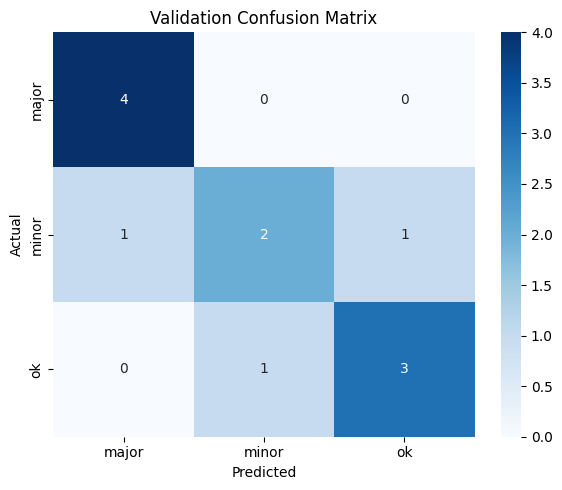


Classification Report:
              precision    recall  f1-score   support

       major       0.80      1.00      0.89         4
       minor       0.67      0.50      0.57         4
          ok       0.75      0.75      0.75         4

    accuracy                           0.75        12
   macro avg       0.74      0.75      0.74        12
weighted avg       0.74      0.75      0.74        12


Run complete and logged to Databricks MLflow
🏃 View run resnet50-finetune at: https://dbc-4b695b7d-0d1d.cloud.databricks.com/ml/experiments/2456829199092442/runs/e45a9d799bce4f528036f13623739193
🧪 View experiment at: https://dbc-4b695b7d-0d1d.cloud.databricks.com/ml/experiments/2456829199092442


In [ ]:
# Cell 9 — Training loop with confusion matrix

import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
epochs = 5

with mlflow.start_run(run_name="resnet50-finetune"):

    mlflow.log_params({
        "epochs": epochs,
        "batch_size": 8,
        "learning_rate": 0.0001,
        "num_classes": num_classes,
        "label_mapping": str(label2id)
    })

    for epoch in range(epochs):

        # Training
        model.train()
        train_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = correct / total if total > 0 else 0

        mlflow.log_metrics({
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_accuracy": val_accuracy
        }, step=epoch)

        print(f"Epoch {epoch+1}/{epochs} — Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.2%}")

    # ── Confusion Matrix ──────────────────────────────────────────
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_true.extend(labels.cpu().numpy())

    class_names = [id2label[i] for i in range(num_classes)]
    cm = confusion_matrix(all_true, all_preds)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Validation Confusion Matrix")
    plt.tight_layout()

    cm_path = "/content/confusion_matrix.png"
    fig.savefig(cm_path)
    mlflow.log_artifact(cm_path)
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_true, all_preds, target_names=class_names))

    # Save and log model
    torch.save(model.state_dict(), "/content/resnet50_claim_model.pt")
    mlflow.log_artifact("/content/resnet50_claim_model.pt")
    print("\nRun complete and logged to Databricks MLflow")

In [ ]:
# Cell 10 — Save label mapping locally

import json

mapping = {"label2id": label2id, "id2label": id2label}
with open("/content/label_mapping.json", "w") as f:
    json.dump(mapping, f)

print("Label mapping saved to /content/label_mapping.json")

Label mapping saved to /content/label_mapping.json


In [ ]:
# Cell 11 — Upload model and label mapping to Databricks Volume

def upload_to_volume(local_path, volume_path):
    upload_url = f"{DATABRICKS_HOST}/api/2.0/fs/files/{volume_path}"
    with open(local_path, "rb") as f:
        r = requests.put(upload_url, headers=headers, data=f)
    assert r.status_code in (200, 204), f"Upload failed for {volume_path}: {r.status_code} {r.text}"
    print(f"Uploaded: {volume_path}")

upload_to_volume(
    "/content/resnet50_claim_model.pt",
    "Volumes/main/default/training_imgs_vol/models/resnet50_claim_model.pt"
)

upload_to_volume(
    "/content/label_mapping.json",
    "Volumes/main/default/training_imgs_vol/models/label_mapping.json"
)

upload_to_volume(
    "/content/confusion_matrix.png",
    "Volumes/main/default/training_imgs_vol/models/confusion_matrix.png"
)

print("\nAll artifacts uploaded to Databricks Volume")

Uploaded: Volumes/main/default/training_imgs_vol/models/resnet50_claim_model.pt
Uploaded: Volumes/main/default/training_imgs_vol/models/label_mapping.json
Uploaded: Volumes/main/default/training_imgs_vol/models/confusion_matrix.png

All artifacts uploaded to Databricks Volume
